# 31 — Map trading desks and positions to IMA risk factors

Show how the same economic position produces SA sensitivities and an IMA historical risk-factor exposure.

A risk factor is a market variable that changes a position value. Sensitivity is the amount by which value changes when that factor moves. The inventory keeps these two ideas separate and retains trade and desk lineage.

This step uses: Trade-level delta and vega mappings from the shared pricing and sensitivity engine.

It produces: One factor inventory and a desk–trade–factor exposure table.

> Basel norm applied: MAR31 requires the internal model to capture all material risk factors used by approved desks.

$$\Delta V_{i,k}\approx s_{i,k}\,\Delta x_k$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
inventory=stage('01_ima_factor_inventory'); exposures=stage('05_factor_exposures')
inventory_sample=inventory[['risk_factor_id','broad_risk_class','desks','trade_count','signed_sensitivity_inr','liquidity_horizon_days','input_data_status']].head(20)
print(f'Displayed sample: first 20 of {len(inventory):,} factors in the full inventory.')
display(inventory_sample)
example=exposures[exposures.trade_id=='R12'][['trade_id','desk','risk_factor_id','broad_risk_class','ima_risk_measure','raw_sensitivity']]
print('The cross-currency basis swap R12 produces these IMA factor exposures:'); display(crore_table(example,['raw_sensitivity']))

Displayed sample: first 20 of 59 factors in the full inventory.


,risk_factor_id,broad_risk_class,desks,trade_count,signed_sensitivity_inr,liquidity_horizon_days,input_data_status
0,APPLE,EQUITY,Equity,1,"92,665,000.0000",10,SYNTHETIC_MARKET_HISTORY
1,AXIS_BANK_5.0Y,CREDIT_SPREAD,Credit,2,"-219,323,260.7983",40,SYNTHETIC_MARKET_HISTORY
2,BRENT_0.25Y_GLOBAL,COMMODITY,Commodity,1,"724,080,000.0000",20,SYNTHETIC_MARKET_HISTORY
3,BRENT_0.5Y_GLOBAL,COMMODITY,Commodity,1,"228,589,330.1703",20,SYNTHETIC_MARKET_HISTORY
4,BRENT_1.0Y_GLOBAL,COMMODITY,Commodity,1,"-579,264,000.0000",20,SYNTHETIC_MARKET_HISTORY
5,BRENT_VOL_0.5Y,COMMODITY,Commodity,1,"31,126,482.1946",60,SYNTHETIC_MARKET_HISTORY
6,CDX_IG_S42_3_7_5.0Y,CREDIT_SPREAD,Credit,1,"-323,250,000.0000",120,SYNTHETIC_MARKET_HISTORY
7,CDX_IG_S42_5.0Y,CREDIT_SPREAD,Credit,1,"215,500,000.0000",120,SYNTHETIC_MARKET_HISTORY
8,EURINR,FX,"Credit, FX, Rates",5,"142,810,002.4777",10,SYNTHETIC_MARKET_HISTORY
9,EURINR_VOL_1.0Y,FX,FX,1,"3,952,624.1622",40,SYNTHETIC_MARKET_HISTORY


The cross-currency basis swap R12 produces these IMA factor exposures:


,trade_id,desk,risk_factor_id,broad_risk_class,ima_risk_measure,Raw Sensitivity (INR crore per unit change)
16,R12,Rates,USD_OIS_5.0Y,INTEREST_RATE,DELTA,-0.0880
17,R12,Rates,INR_OIS_5.0Y,INTEREST_RATE,DELTA,-0.0771
18,R12,Rates,INR_OVER_USD_BASIS,INTEREST_RATE,DELTA,66.0303
19,R12,Rates,USDINR,FX,DELTA,0.0330


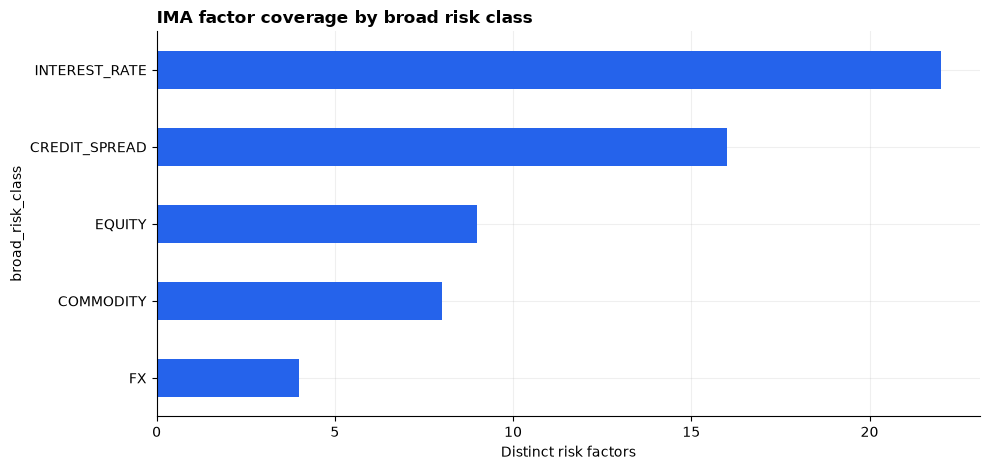

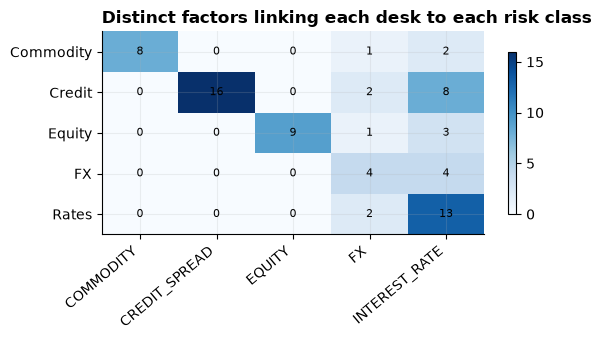

In [3]:
counts=inventory.groupby('broad_risk_class').risk_factor_id.nunique().sort_values()
ax=counts.plot(kind='barh',color='#2563EB'); ax.set_xlabel('Distinct risk factors'); ax.set_title('IMA factor coverage by broad risk class',loc='left',weight='bold'); plt.tight_layout(); plt.show()
desk_factor=exposures.groupby(['desk','broad_risk_class']).risk_factor_id.nunique().unstack(fill_value=0)
heatmap(desk_factor,'Distinct factors linking each desk to each risk class',value_format='.0f')

The first chart counts distinct IMA factors in each broad risk class and therefore shows where the model has the greatest factor granularity. The heatmap then shows which desks are exposed to those classes. A darker cell means that a desk is connected to more distinct factors in that risk class; it does not indicate a larger monetary sensitivity.